In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data generation
from src.data_generation.representation_bias_world import simulate_representation_bias_world

# Preprocessing
from src.training.preprocessing import split_data, scale_data

# Logistic Regression
from src.training.train_lr import train_logistic_regression

# MLP + training curves
from src.training.train_mlp import train_mlp_model, plot

# Fairness metrics
from src.metrics.fairness import fairness_by_group, equal_opportunity_diff

print("Imports OK")


Imports OK


In [21]:
# Create dataset with a minority group representing only 10% of population
df = simulate_representation_bias_world(n_samples=10000, minority_frac=0.10)

df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,1,41.651611,90.085338,5.579520,0
1,0,0,57.408278,81.567893,5.381957,0
2,0,1,65.707111,95.116469,4.982591,0
3,0,0,55.296478,104.610219,5.286985,0
4,0,1,75.905415,172.081356,7.899724,1


In [22]:
df["race"].value_counts(normalize=True)


race
0    0.698740
1    0.282832
2    0.018428
Name: proportion, dtype: float64

In [23]:
features = ["glucose_measured", "hba1c_measured", "age"]
target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)
X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Prevalence:", y_train.mean())


Train size: 6859
Test size: 1715
Prevalence: 0.20294503571949263


In [24]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

lr_results


{'model': LogisticRegression(max_iter=2000),
 'pred': array([0, 0, 0, ..., 1, 0, 0], shape=(1715,)),
 'probs': array([2.94810049e-05, 3.54523650e-05, 4.30209495e-04, ...,
        9.99997241e-01, 1.71877645e-03, 1.76127783e-03], shape=(1715,)),
 'accuracy': 0.9994169096209913,
 'AUROC': 0.9999912279547537}

Epoch 1/20: train_loss=0.1767, train_acc=96.02, val_loss=0.0106, val_acc=99.88
Epoch 2/20: train_loss=0.0088, train_acc=99.84, val_loss=0.0043, val_acc=99.94
Epoch 3/20: train_loss=0.0056, train_acc=99.85, val_loss=0.0029, val_acc=99.94
Epoch 4/20: train_loss=0.0047, train_acc=99.87, val_loss=0.0026, val_acc=99.94
Epoch 5/20: train_loss=0.0041, train_acc=99.90, val_loss=0.0034, val_acc=99.83
Epoch 6/20: train_loss=0.0039, train_acc=99.87, val_loss=0.0023, val_acc=99.94
Epoch 7/20: train_loss=0.0035, train_acc=99.88, val_loss=0.0023, val_acc=99.94
Epoch 8/20: train_loss=0.0034, train_acc=99.88, val_loss=0.0023, val_acc=99.94
Epoch 9/20: train_loss=0.0033, train_acc=99.88, val_loss=0.0024, val_acc=99.94
Epoch 10/20: train_loss=0.0032, train_acc=99.91, val_loss=0.0026, val_acc=99.94
Epoch 11/20: train_loss=0.0030, train_acc=99.90, val_loss=0.0026, val_acc=99.94
Epoch 12/20: train_loss=0.0029, train_acc=99.91, val_loss=0.0026, val_acc=99.94
Epoch 13/20: train_loss=0.0028, train_acc=99.91, 

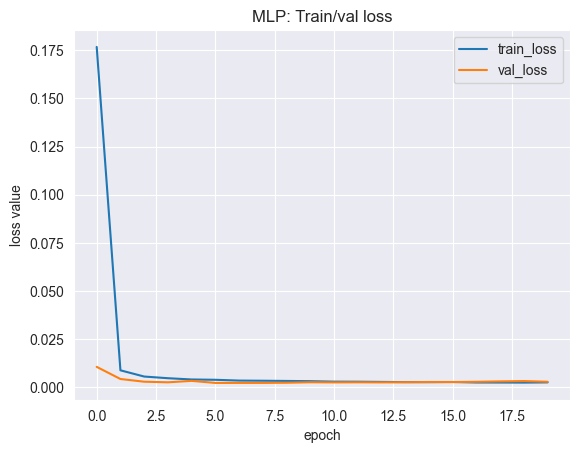

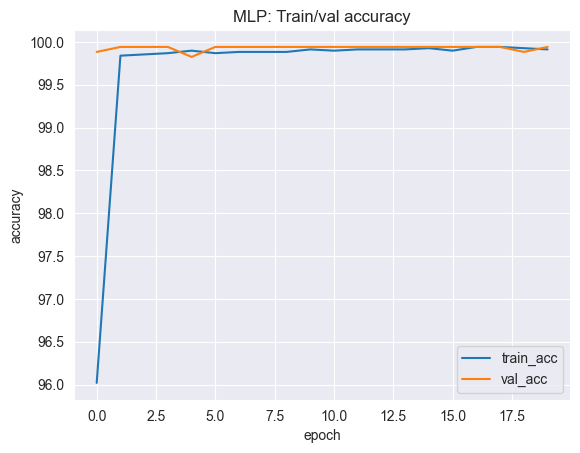

In [25]:
input_dim = len(features)

mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=input_dim,
    hidden_dim=32,
    n_epochs=20,
    lr=0.001
)


In [26]:
race_test = df.loc[X_test.index, "race"]
gender_test = df.loc[X_test.index, "gender"]

print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], race_test)
display(lr_fair_race)

print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], race_test)
display(mlp_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], gender_test)
display(lr_fair_gender)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], gender_test)
display(mlp_fair_gender)


=== LR Fairness by Race ===


,FPR,FNR,TPR,TNR
0,0.0,0.000000,1.000000,1.0
1,0.0,0.011364,0.988636,1.0
2,0.0,0.000000,1.000000,1.0



=== MLP Fairness by Race ===


,FPR,FNR,TPR,TNR
0,0.0,0.000000,1.000000,1.0
1,0.0,0.011364,0.988636,1.0
2,0.0,0.000000,1.000000,1.0



=== LR Fairness by Gender ===


,FPR,FNR,TPR,TNR
0,0.0,0.000000,1.000000,1.0
1,0.0,0.006211,0.993789,1.0



=== MLP Fairness by Gender ===


,FPR,FNR,TPR,TNR
0,0.0,0.000000,1.000000,1.0
1,0.0,0.006211,0.993789,1.0


In [27]:
LR_EO_race   = equal_opportunity_diff(lr_fair_race)
MLP_EO_race  = equal_opportunity_diff(mlp_fair_race)

LR_EO_gender = equal_opportunity_diff(lr_fair_gender)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)

results_repr = {
    "world_name": "RepresentationBias",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_repr


{'world_name': 'RepresentationBias',
 'LR_accuracy': 0.9994169096209913,
 'LR_AUROC': 0.9999912279547537,
 'LR_EO_race': 0.011363636363636354,
 'LR_EO_gender': 0.006211180124223614,
 'MLP_accuracy': np.float64(0.9994169096209913),
 'MLP_AUROC': 0.9999824559095076,
 'MLP_EO_race': 0.011363636363636354,
 'MLP_EO_gender': 0.006211180124223614}

In [28]:
from src.training.preprocessing import scale_data  # to rescale after oversampling

# Build train DataFrame (so we have race + features + label)
train_df = df.loc[X_train.index].copy()

# Identify minority race automatically (smallest count)
race_counts = train_df["race"].value_counts()
print("Train race counts:\n", race_counts)

minority_race = race_counts.idxmin()
print("Minority race:", minority_race)

# Split majority / minority
minor_df = train_df[train_df["race"] == minority_race]
major_df = train_df[train_df["race"] != minority_race]

print("Minority size:", len(minor_df), "Majority size:", len(major_df))

# Oversample minority to match majority size
desired_minority = len(major_df)
oversampled_minor = minor_df.sample(
    n=desired_minority,
    replace=True,
    random_state=42
)

train_os_df = pd.concat([major_df, oversampled_minor]).sample(
    frac=1.0, random_state=42
)

train_os_df["race"].value_counts()


Train race counts:
 race
0    4803
1    1931
2     125
Name: count, dtype: int64
Minority race: 2
Minority size: 125 Majority size: 6734


race
2    6734
0    4803
1    1931
Name: count, dtype: int64

In [29]:
X_train_os = train_os_df[features]
y_train_os = train_os_df[target]

# Rescale using oversampled train
X_train_os_s, X_test_os_s, scaler_os = scale_data(X_train_os, X_test)

print("Original train size:", len(X_train))
print("Oversampled train size:", len(X_train_os))


Original train size: 6859
Oversampled train size: 13468


LR (oversampled) accuracy: 0.9994169096209913
LR (oversampled) AUROC: 0.9999912279547537
Epoch 1/20: train_loss=0.0785, train_acc=99.52, val_loss=0.0047, val_acc=99.94
Epoch 2/20: train_loss=0.0030, train_acc=99.93, val_loss=0.0027, val_acc=99.94
Epoch 3/20: train_loss=0.0022, train_acc=99.96, val_loss=0.0024, val_acc=99.94
Epoch 4/20: train_loss=0.0020, train_acc=99.94, val_loss=0.0026, val_acc=99.94
Epoch 5/20: train_loss=0.0019, train_acc=99.97, val_loss=0.0025, val_acc=99.94
Epoch 6/20: train_loss=0.0017, train_acc=99.94, val_loss=0.0024, val_acc=99.94
Epoch 7/20: train_loss=0.0016, train_acc=99.95, val_loss=0.0031, val_acc=99.88
Epoch 8/20: train_loss=0.0015, train_acc=99.96, val_loss=0.0027, val_acc=99.94
Epoch 9/20: train_loss=0.0016, train_acc=99.95, val_loss=0.0032, val_acc=99.88
Epoch 10/20: train_loss=0.0017, train_acc=99.95, val_loss=0.0025, val_acc=99.94
Epoch 11/20: train_loss=0.0014, train_acc=99.96, val_loss=0.0031, val_acc=99.94
Epoch 12/20: train_loss=0.0015, train_ac

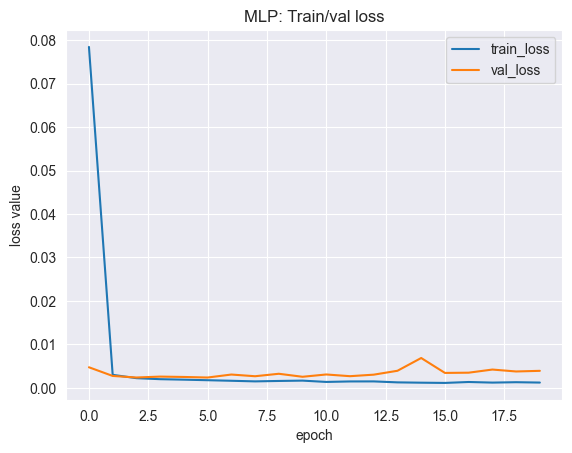

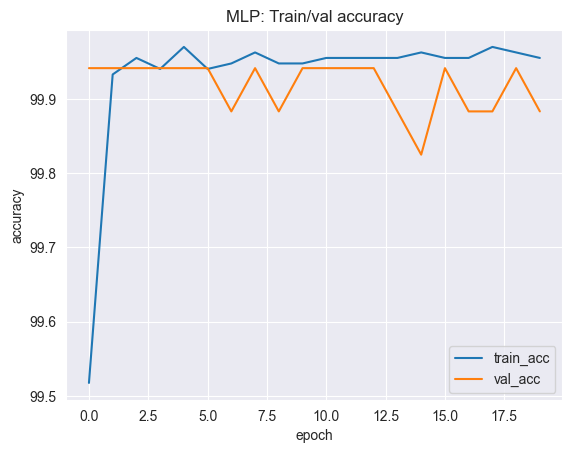

In [30]:
# LR on oversampled
lr_os_results = train_logistic_regression(
    X_train_os_s, y_train_os,
    X_test_os_s, y_test
)

print("LR (oversampled) accuracy:", lr_os_results["accuracy"])
print("LR (oversampled) AUROC:", lr_os_results["AUROC"])

# MLP on oversampled
mlp_os_results = train_mlp_model(
    X_train_os_s, y_train_os,
    X_test_os_s, y_test,
    input_dim=len(features),
    hidden_dim=32,
    n_epochs=20,
    lr=0.001
)

print("MLP (oversampled) accuracy:", mlp_os_results["accuracy"])
print("MLP (oversampled) AUROC:", mlp_os_results["AUROC"])


In [31]:
# Sensitive attributes on test
race_test   = df.loc[X_test.index, "race"]
gender_test = df.loc[X_test.index, "gender"]

print("=== LR Fairness BEFORE (Race) ===")
lr_fair_race_before = fairness_by_group(y_test, lr_results["pred"], race_test)
display(lr_fair_race_before)
LR_EO_race_before = equal_opportunity_diff(lr_fair_race_before)

print("\n=== LR Fairness AFTER Oversampling (Race) ===")
lr_fair_race_after = fairness_by_group(y_test, lr_os_results["pred"], race_test)
display(lr_fair_race_after)
LR_EO_race_after = equal_opportunity_diff(lr_fair_race_after)

print("\nLR EO Race: before =", LR_EO_race_before, ", after =", LR_EO_race_after)


print("\n=== MLP Fairness BEFORE (Race) ===")
mlp_fair_race_before = fairness_by_group(y_test, mlp_results["pred"], race_test)
display(mlp_fair_race_before)
MLP_EO_race_before = equal_opportunity_diff(mlp_fair_race_before)

print("\n=== MLP Fairness AFTER Oversampling (Race) ===")
mlp_fair_race_after = fairness_by_group(y_test, mlp_os_results["pred"], race_test)
display(mlp_fair_race_after)
MLP_EO_race_after = equal_opportunity_diff(mlp_fair_race_after)

print("\nMLP EO Race: before =", MLP_EO_race_before, ", after =", MLP_EO_race_after)


=== LR Fairness BEFORE (Race) ===


,FPR,FNR,TPR,TNR
0,0.0,0.000000,1.000000,1.0
1,0.0,0.011364,0.988636,1.0
2,0.0,0.000000,1.000000,1.0



=== LR Fairness AFTER Oversampling (Race) ===


,FPR,FNR,TPR,TNR
0,0.0,0.000000,1.000000,1.0
1,0.0,0.011364,0.988636,1.0
2,0.0,0.000000,1.000000,1.0



LR EO Race: before = 0.011363636363636354 , after = 0.011363636363636354

=== MLP Fairness BEFORE (Race) ===


,FPR,FNR,TPR,TNR
0,0.0,0.000000,1.000000,1.0
1,0.0,0.011364,0.988636,1.0
2,0.0,0.000000,1.000000,1.0



=== MLP Fairness AFTER Oversampling (Race) ===


,FPR,FNR,TPR,TNR
0,0.00105,0.000000,1.000000,0.99895
1,0.00000,0.011364,0.988636,1.00000
2,0.00000,0.000000,1.000000,1.00000



MLP EO Race: before = 0.011363636363636354 , after = 0.011363636363636354
